# Irish Property Developer: Rental Tier Classification Model
## 1. Business Problem Definition

**Organisation:** A mid-sized Irish property development firm operating across all 26 counties of the Republic of Ireland.

**Context:** The firm develops residential properties and prices them across a tiered scale Budget, Standard and Luxury to target distinct buyer and renter segments. Before committing capital to a site acquisition or development, the firm needs to determine which tier a proposed property will fall into and what market-supported rent or price it can achieve.

Currently, pricing decisions rely on senior staff experience and expensive periodic third-party valuations. This process is slow, inconsistent across sites, and difficult to scale as the firm expands into new counties.

**Scope clarification:** This model uses rental price data as the primary pricing signal. Rental prices in Ireland are strongly correlated with sale prices at the county and bedroom-type level, making them a valid and data rich proxy for development pricing, particularly for build-to-rent and private rental sector schemes which are a growing part of the Irish market. The model is therefore framed as a rental tier classifier, directly applicable to private rental sector development appraisals.

**Business Risks Without a Model:**
- **Over-pricing:** Properties sit vacant, tying up capital and incurring holding costs.
- **Under-pricing:** Margin is left on the table, reducing project ROI.
- **Misclassification:** A property positioned as Luxury when the evidence supports Standard leads to wrong specification, wrong marketing spend, and wrong buyer/tenant targeting.

**Goal:** Build a data-driven model that classifies proposed Irish residential properties into one of three price tiers Budget/ Standard / Luxury using county and property level features drawn from openly available Irish data sources.

---
## 2. Data Sources

All data sources are publicly available from Irish sources.

| # | Source | URL | Format | Content |
|---|--------|-----|--------|---------|
| 1 | RTB Average Monthly Rent Report | https://data.gov.ie/dataset/ria02-rtb-average-monthly-rent-report | CSV | Average monthly rent per property by county, bedroom type, and property type |
| 2 | Revenue Net Receipts by County | https://data.gov.ie/dataset/revenue-net-receipts-by-county | CSV | County-level VAT, PAYE/USC, self-employed tax, corporation tax, CGT |
| 3 | Population per County | https://data.gov.ie/dataset/g0420-population-per-county | CSV | 2022 census population per county |
| 4 | Mean Net Household Income by County | https://data.cso.ie/GPIIA02 | CSV | CSO mean net household income per county (2022) |
| 5 | Average Agricultural Land Price by County | https://teagasc.ie/news--events/daily/map-land-prices-by-county/ | Manual (TXT) | Teagasc county-level average land price per acre (€), manually transcribed from published map visual |

**Note on Source 5 (Teagasc land prices):** As no machine readable download was available, values were manually recorded from the Teagasc published county map. Each county was matched by name and the published average price per acre was recorded. This introduces a minor transcription risk but the data is published by a credible Irish state agency (Teagasc the Agriculture and Food Development Authority). This is acknowledged as a limitation.



### Local Context Features
Two features in this dataset require specific knowledge of the Irish context:

1. **paye_income_tax_and_usc_€m** This feature includes the Universal Social Charge (USC), a tax unique to Ireland introduced during the 2008–2010 financial crisis. USC is levied on gross income above a threshold and is specific to the Irish tax system. Higher USC/PAYE receipts at county level indicate higher employment density and income levels, which directly influence rental demand and achievable price tiers.

2. **Land_Price** Land prices in Ireland are heavily shaped by Irish-specific policy: the Residential Zoned Land Tax, and planning permission scarcity in particular Local Authority areas. Teagasc land prices reflect the Irish agricultural land market, which underpins site acquisition costs for residential development.

---
## 3. Task Definitions

### Clustering Task
**Objective:** Two unsupervised clustering algorithms are applied, K-Means (k=3) and Agglomerative Hierarchical Clustering (k=3, Ward linkage). These are applied to the data with no knowledge of the manually assigned tier labels. The goal is simply to see whether the data finds its own natural groupings, and whether those groupings end up looking anything like the property market segments we'd expect.

After clustering, each group is examined to see how it lines up with the manually assigned labels. Silhouette score is then used to compare both algorithms and work out which model gives a more meaningful picture of the Irish rental market.

**Features used for clustering:** Rent_Price, Land_Price, Population of County, Average_Value_County, Net_Income, Average_Value_Bedroom_Count

**Business value:** If the data splits into three recognisable market segments on its own, that provides rational to the three-tier framework and suggests the labels are capturing something genuine. It can also surface properties that sit awkwardly within their county group, which may be important to define mispricing. 
### Multiclass Classification Task
**Objective:** Two supervised classifiers, Logistic Regression and Random Forest, are trained and compared on the task of predicting the Price_Category label (Budget / Standard / Luxury) from a property's county-level and property-level features.

- **Logistic Regression** acts as the baseline. Its coefficients are easy to read and make it simple to explain why a property was assigned to a particular tier.
- **Random Forest** is the main model being evaluated. It works across an ensemble of decision trees, which means it can pick up on patterns and feature interactions that a straight linear model would miss. It also produces feature importance scores which are important for answering *which factors best determine a property's tier?*

**Target variable:** Price_Category, a three-class label (Budget / Standard / Luxury) derived from Rent_Price percentile thresholds as set out in Section 5.

**Features used:** All numeric columns after redundant identifiers are removed. Both models are run on the same 80/20 split and use class_weight='balanced' to stop any imbalance between class sizes from skewing results.

**Business value:** With a working classifier in place, the development team can put in the relevant details for a proposed site and get back a tier prediction straight away rather than waiting on a manual valuation. The Random Forest importance scores are also useful for working out which pieces of information are most influential when scoping out future sites.

---
## 4. Dataset Creation

Some preprocessing was done in excel to remove redundant and missing variables 

The following pipeline was followed in python:
1. Load each CSV source
2. Standardise county names and filter to year 2022 in Python (no external Excel preprocessing)
3. Engineer two derived features
4. Merge all sources on County
5. Drop redundant columns
6. Save the final dataset

**Feature inventory (10 analytical features used in modelling):**

| # | Feature | Type | Source |
|---|---------|------|--------|
| 1 | Rent_Price | Continuous | Residential Tenancies Board |
| 2 | Land_Price | Continuous | Teagasc (local context) |
| 3 | Population of County | Continuous | CSO Census |
| 4 | Rent_Land_Ratio | Derived | Engineered |
| 5 | vat_internal_€m | Continuous | Revenue |
| 6 | paye_income_tax_and_usc_€m | Continuous | Revenue (local context - USC) |
| 7 | self_employed_income_tax_€m | Continuous | Revenue |
| 8 | corporation_tax_€m| Continuous | Revenue |
| 9 | capital_gains_tax_€m | Continuous | Revenue |
| 10 |VALUE (Net_Income) | Continuous | CSO Income Survey |

In [1]:
import pandas as pd
import numpy as np 

from sklearn.cluster import KMeans
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
df = pd.read_csv('RentPrice.csv')

In [3]:
df2 = pd.read_csv('net-receipts-by-county.csv')

In [4]:
df2.rename(columns={'county': 'County'}, inplace=True)

In [5]:
df2.head()

,County,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m
0,Carlow,86.53,147.83,25.62,33.55,7.19
1,Cavan,115.04,196.23,30.28,77.63,7.47
2,Clare,168.66,380.60,50.19,136.84,15.83
3,Cork,1818.53,2259.48,341.84,8467.08,184.82
4,Donegal,151.96,202.12,48.96,78.69,13.88


In [6]:
df3 = pd.read_csv('Income_Data.csv')

In [7]:
df3['County'] = df3['County'].str.replace('Co. ', '', regex=False)

In [8]:
df3.head()

,Statistic Label,Year,County,VALUE
0,Mean Net Household Income,2022,Clare,55072
1,Mean Net Household Income,2022,Cork,60620
2,Mean Net Household Income,2022,Cavan,52780
3,Mean Net Household Income,2022,Carlow,53953
4,Mean Net Household Income,2022,Donegal,45840


In [9]:
df.head()

,Year,Number of Bedrooms,Property Type,County,UNIT,Rent_Price,Land_Price,Population of County
0,2022,Four plus bed,All property types,Carlow,Euro,1397.92,17417,61968
1,2022,Four plus bed,All property types,Carlow,Euro,1323.98,17417,61968
2,2022,All bedrooms,All property types,Carlow,Euro,1060.03,17417,61968
3,2022,Three bed,All property types,Carlow,Euro,1028.83,17417,61968
4,2022,All bedrooms,All property types,Carlow,Euro,1017.06,17417,61968


In [10]:
df.describe()

,Year,Rent_Price,Land_Price,Population of County
count,1925.0,1925.000000,1925.000000,1.925000e+03
mean,2022.0,1284.690218,16013.714286,6.372986e+05
std,0.0,527.320353,3467.627036,6.036778e+05
min,2022.0,496.050000,7625.000000,3.519900e+04
25%,2022.0,860.440000,14500.000000,1.379700e+05
50%,2022.0,1166.980000,17875.000000,2.477740e+05
75%,2022.0,1635.720000,18395.000000,1.458154e+06
max,2022.0,4324.510000,23000.000000,1.458154e+06


In [11]:
# Average rent by bedroom type
df['Avg_Rent_By_Bedroom'] = df.groupby('Number of Bedrooms')['Rent_Price'].transform('mean')

# Rent to land price ratio
df['Rent_Land_Ratio'] = df['Rent_Price'] / df['Land_Price']

In [12]:
Data_set_1 = df

In [13]:
Data_set_1.head()

,Year,Number of Bedrooms,Property Type,County,UNIT,Rent_Price,Land_Price,Population of County,Avg_Rent_By_Bedroom,Rent_Land_Ratio
0,2022,Four plus bed,All property types,Carlow,Euro,1397.92,17417,61968,1680.863733,0.080262
1,2022,Four plus bed,All property types,Carlow,Euro,1323.98,17417,61968,1680.863733,0.076017
2,2022,All bedrooms,All property types,Carlow,Euro,1060.03,17417,61968,1298.127292,0.060862
3,2022,Three bed,All property types,Carlow,Euro,1028.83,17417,61968,1385.131496,0.059070
4,2022,All bedrooms,All property types,Carlow,Euro,1017.06,17417,61968,1298.127292,0.058395


In [14]:
df4 = Data_set_1.merge(df2, on='County', how='left')

In [15]:
print(f"After merge 1 (RTB + Revenue): {df4.shape}")
print(f"Nulls introduced: {df4.isnull().sum().sum()}")

After merge 1 (RTB + Revenue): (1925, 15)
Nulls introduced: 0


In [16]:
df4.to_csv('merged.csv', index=False)

In [17]:
Data_set_2 = pd.read_csv('merged.csv')

In [18]:
Data_set_2.head()

,Year,Number of Bedrooms,Property Type,County,UNIT,Rent_Price,Land_Price,Population of County,Avg_Rent_By_Bedroom,Rent_Land_Ratio,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m
0,2022,Four plus bed,All property types,Carlow,Euro,1397.92,17417,61968,1680.863733,0.080262,86.53,147.83,25.62,33.55,7.19
1,2022,Four plus bed,All property types,Carlow,Euro,1323.98,17417,61968,1680.863733,0.076017,86.53,147.83,25.62,33.55,7.19
2,2022,All bedrooms,All property types,Carlow,Euro,1060.03,17417,61968,1298.127292,0.060862,86.53,147.83,25.62,33.55,7.19
3,2022,Three bed,All property types,Carlow,Euro,1028.83,17417,61968,1385.131496,0.059070,86.53,147.83,25.62,33.55,7.19
4,2022,All bedrooms,All property types,Carlow,Euro,1017.06,17417,61968,1298.127292,0.058395,86.53,147.83,25.62,33.55,7.19


In [19]:
df5 = Data_set_2.merge(df3,on='County', how='left')

In [20]:
print(f"After merge 2 (+ Income): {df5.shape}")
print(f"Nulls introduced: {df5.isnull().sum().sum()}")

After merge 2 (+ Income): (1925, 18)
Nulls introduced: 0


In [21]:
df5.head()

,Year_x,Number of Bedrooms,Property Type,County,UNIT,Rent_Price,Land_Price,Population of County,Avg_Rent_By_Bedroom,Rent_Land_Ratio,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,Statistic Label,Year_y,VALUE
0,2022,Four plus bed,All property types,Carlow,Euro,1397.92,17417,61968,1680.863733,0.080262,86.53,147.83,25.62,33.55,7.19,Mean Net Household Income,2022,53953
1,2022,Four plus bed,All property types,Carlow,Euro,1323.98,17417,61968,1680.863733,0.076017,86.53,147.83,25.62,33.55,7.19,Mean Net Household Income,2022,53953
2,2022,All bedrooms,All property types,Carlow,Euro,1060.03,17417,61968,1298.127292,0.060862,86.53,147.83,25.62,33.55,7.19,Mean Net Household Income,2022,53953
3,2022,Three bed,All property types,Carlow,Euro,1028.83,17417,61968,1385.131496,0.059070,86.53,147.83,25.62,33.55,7.19,Mean Net Household Income,2022,53953
4,2022,All bedrooms,All property types,Carlow,Euro,1017.06,17417,61968,1298.127292,0.058395,86.53,147.83,25.62,33.55,7.19,Mean Net Household Income,2022,53953


Certain redunent columns will be dropped as they will not aid in clustering and future analysis.
 
The following variables were removed as they were repeating values that do not aid with analysis or clustering these variables are: Property Type, UNIT, Both Year columns, UNIT and Statistic label.

In [22]:
df5.drop(columns=['Property Type', 'UNIT', 'Statistic Label','Year_y','Year_x'], inplace=True)

In [23]:
df5.head()

,Number of Bedrooms,County,Rent_Price,Land_Price,Population of County,Avg_Rent_By_Bedroom,Rent_Land_Ratio,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,VALUE
0,Four plus bed,Carlow,1397.92,17417,61968,1680.863733,0.080262,86.53,147.83,25.62,33.55,7.19,53953
1,Four plus bed,Carlow,1323.98,17417,61968,1680.863733,0.076017,86.53,147.83,25.62,33.55,7.19,53953
2,All bedrooms,Carlow,1060.03,17417,61968,1298.127292,0.060862,86.53,147.83,25.62,33.55,7.19,53953
3,Three bed,Carlow,1028.83,17417,61968,1385.131496,0.059070,86.53,147.83,25.62,33.55,7.19,53953
4,All bedrooms,Carlow,1017.06,17417,61968,1298.127292,0.058395,86.53,147.83,25.62,33.55,7.19,53953


In [24]:
df5

,Number of Bedrooms,County,Rent_Price,Land_Price,Population of County,Avg_Rent_By_Bedroom,Rent_Land_Ratio,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,VALUE
0,Four plus bed,Carlow,1397.92,17417,61968,1680.863733,0.080262,86.53,147.83,25.62,33.55,7.19,53953
1,Four plus bed,Carlow,1323.98,17417,61968,1680.863733,0.076017,86.53,147.83,25.62,33.55,7.19,53953
2,All bedrooms,Carlow,1060.03,17417,61968,1298.127292,0.060862,86.53,147.83,25.62,33.55,7.19,53953
3,Three bed,Carlow,1028.83,17417,61968,1385.131496,0.059070,86.53,147.83,25.62,33.55,7.19,53953
4,All bedrooms,Carlow,1017.06,17417,61968,1298.127292,0.058395,86.53,147.83,25.62,33.55,7.19,53953
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1920,Two bed,Wicklow,981.22,15500,155851,1274.983380,0.063305,243.70,263.37,103.30,72.16,64.99,63733
1921,1 to 2 bed,Wicklow,960.50,15500,155851,1184.009032,0.061968,243.70,263.37,103.30,72.16,64.99,63733
1922,1 to 2 bed,Wicklow,940.06,15500,155851,1184.009032,0.060649,243.70,263.37,103.30,72.16,64.99,63733
1923,One bed,Wicklow,864.47,15500,155851,1057.093690,0.055772,243.70,263.37,103.30,72.16,64.99,63733


In [25]:
print(f"\nMerge Validation Summary")
print(f"Original RTB rows:     {len(df)}")
print(f"After merge 1 (Revenue): {len(df4)}")
print(f"After merge 2 (Income):  {len(df5)}")
print(f"Row count preserved:   {len(df) == len(df5)}")
print(f"Total nulls in final dataset: {df5.isnull().sum().sum()}")


Merge Validation Summary
Original RTB rows:     1925
After merge 1 (Revenue): 1925
After merge 2 (Income):  1925
Row count preserved:   True
Total nulls in final dataset: 0


In [26]:
df5.to_csv('Final_Cleaned_Group_Project.csv')

---
## 5. Label Creation

### Process

The target variable Price_Category is created using **percentile-based thresholds on Rent_Price**. This approach is chosen because:

- Rent_Price is the primary market signal and directly reflects what tenants/buyers are willing to pay in each county/bedroom segment
- Percentile thresholds are data-driven and avoid arbitrary fixed euro boundaries that may not reflect the 2022 Irish market
- Three tiers are used to ensure meaningful, balanced class sizes for model training

### Threshold Justification (aligned with Irish market, 2022)

| Tier | Percentile Range | Approx Rent Range | Market Rationale |
|------|-----------------|-------------------|------------------|
| **Budget** | 0–25th | Up to ~€860/month | Rural and Border counties (Leitrim, Roscommon, Longford), 1–2 bed units, at or below HAP payment limits in most Local Authority areas |
| **Standard** | 25th–75th | ~€860–€1,636/month | Commuter counties (Meath, Kildare, Wicklow), regional cities (Cork, Galway, Limerick) 2-3 bed family homes forming the mainstream Irish rental market |
| **Luxury** | 75th–100th | Above ~€1,636/month | Dublin city and inner suburbs, 3–4+ bed properties, top-end private residential sector and owner-occupier stock where rents significantly exceed national median |

### Label Creation Code
Labels are assigned programmatically using pd.qcut with the quantile boundaries above. The column is named Price_Category and inserted as the second column in the dataset.

### Alignment with Business Problem
These thresholds reflect the Irish private rental market's real segmentation. The 25th percentile (~€860) marks the boundary where properties compete with cost-rental and Local Authority housing schemes, and where HAP limits begin to constrain achievable rents in many counties. The 75th percentile (~€1,636) captures the point at which the Dublin premium effect becomes dominant properties above this level are predominantly Dublin city properties and command a luxury positioning. The three-tier structure provides clear, actionable guidance for the development team: Budget sites require cost-control specification, Standard sites target mainstream PRS demand, and Luxury sites justify premium fit-out and marketing spend.

In [27]:
df_with_class = pd.read_csv("Final_Cleaned_Group_Project.csv")

In [28]:
df_with_class.rename(columns= {'VALUE' : 'Net_Income'},inplace=True)

In [29]:
price_labels = ['Budget', 'Standard', 'Luxury']

new_column = pd.qcut(df_with_class['Rent_Price'],  q=[0, 0.25, 0.75,  1], labels = price_labels)


df_with_class.insert(1, 'Price_Category', new_column)

df_with_class.head()

,Unnamed: 0,Price_Category,Number of Bedrooms,County,Rent_Price,Land_Price,Population of County,Avg_Rent_By_Bedroom,Rent_Land_Ratio,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,Net_Income
0,0,Standard,Four plus bed,Carlow,1397.92,17417,61968,1680.863733,0.080262,86.53,147.83,25.62,33.55,7.19,53953
1,1,Standard,Four plus bed,Carlow,1323.98,17417,61968,1680.863733,0.076017,86.53,147.83,25.62,33.55,7.19,53953
2,2,Standard,All bedrooms,Carlow,1060.03,17417,61968,1298.127292,0.060862,86.53,147.83,25.62,33.55,7.19,53953
3,3,Standard,Three bed,Carlow,1028.83,17417,61968,1385.131496,0.059070,86.53,147.83,25.62,33.55,7.19,53953
4,4,Standard,All bedrooms,Carlow,1017.06,17417,61968,1298.127292,0.058395,86.53,147.83,25.62,33.55,7.19,53953


In [30]:
df_with_class.drop(columns=['Unnamed: 0'], inplace=True)

In [31]:
df_with_class.value_counts('Price_Category')

Price_Category
Standard    962
Budget      482
Luxury      481
Name: count, dtype: int64

In [32]:
df_with_class.to_csv("Data_with_class.csv",index= False)

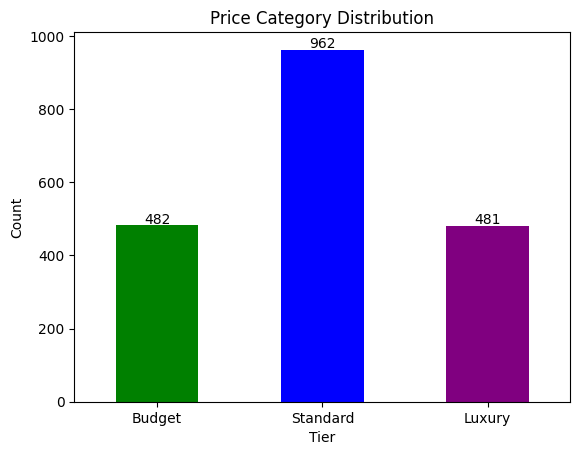

In [33]:
counts = df_with_class['Price_Category'].value_counts().reindex(['Budget', 'Standard', 'Luxury'])
ax = counts.plot(kind='bar', color=['green', 'blue', 'purple'])
for i, val in enumerate(counts.values):
    ax.text(i, val + 5, str(val), ha='center')
plt.title('Price Category Distribution')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** The three tiers are distributed as follows: Budget (25% of records, 482 properties), Standard (50%, 962 properties), and Luxury (25%, 481 properties). The larger Standard class reflects the dominance of mid-market stock in the Irish rental dataset. The Budget and Luxury classes are equal in size by construction of the percentile boundaries. This moderate class imbalance, Standard is twice the size of Budget or Luxury justifies the use of class_weight='balanced' in both classifiers, which re-weights the loss function to prevent the model from defaulting to the majority class.

---
## 6. Exploratory Data Analysis

The EDA is structured to:
1. Understand the distribution of the key features
2. Examine the class label distribution
3. Identify which features differ meaningfully across tiers
4. Surface geographic patterns relevant to the Irish property market
5. Assess correlations between features

In [34]:
df_with_class.describe()

,Rent_Price,Land_Price,Population of County,Avg_Rent_By_Bedroom,Rent_Land_Ratio,vat_internal_€m,paye_income_tax_and_usc_€m,self_employed_income_tax_€m,corporation_tax_€m,capital_gains_tax_€m,Net_Income
count,1925.000000,1925.000000,1.925000e+03,1925.000000,1925.000000,1925.000000,1925.000000,1925.000000,1925.000000,1925.000000,1925.000000
mean,1284.690218,16013.714286,6.372986e+05,1284.690218,0.080455,3657.059086,5101.696997,544.158005,4747.474992,306.973210,61734.438442
std,527.320353,3467.627036,6.036778e+05,142.942849,0.026705,4504.095165,6147.370398,607.906178,5387.268030,351.397356,8024.357715
min,496.050000,7625.000000,3.519900e+04,1057.093690,0.027767,21.170000,69.210000,12.310000,12.440000,4.640000,45840.000000
25%,860.440000,14500.000000,1.379700e+05,1230.715246,0.060736,158.650000,263.370000,59.520000,78.690000,25.400000,54423.000000
50%,1166.980000,17875.000000,2.477740e+05,1274.983380,0.078725,376.520000,1018.220000,120.420000,276.810000,74.210000,60620.000000
75%,1635.720000,18395.000000,1.458154e+06,1298.127292,0.095402,9895.730000,13623.770000,1383.090000,11525.390000,792.110000,70886.000000
max,4324.510000,23000.000000,1.458154e+06,1680.863733,0.235092,9895.730000,13623.770000,1383.090000,11525.390000,792.110000,70886.000000


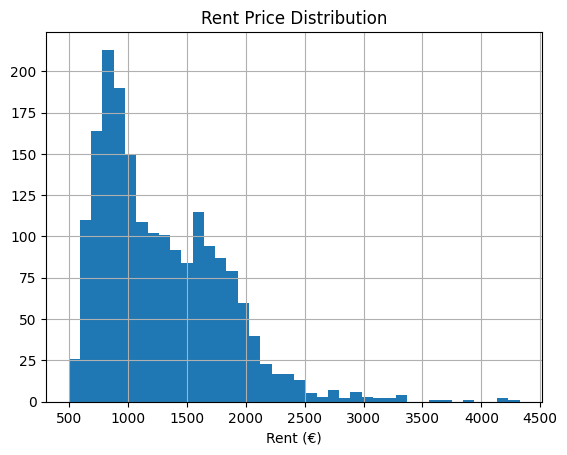

In [35]:
df_with_class['Rent_Price'].hist(bins=40)
plt.title('Rent Price Distribution')
plt.xlabel('Rent (€)')
plt.show()

**Interpretation:** The rent price distribution is strongly right-skewed, with the majority of properties
clustering between €500 and €2,500 per month. The peak frequency occurs around €800-€900, representing
the most common rental price point in the Irish market consistent with one-bed and two-bed properties
in non-Dublin counties. The secondary bump visible around €1,500-€1,700 reflects the Dublin market
creating a distinct second concentration of higher-priced rentals. The long tail extending to €4,500
represents a small number of luxury properties, predominantly large multi-bed units in
South Dublin. This skew confirms that a simple mean would misrepresent the typical Irish rental price
and that percentile-based tier thresholds are more appropriate than fixed euro boundaries for label creation.

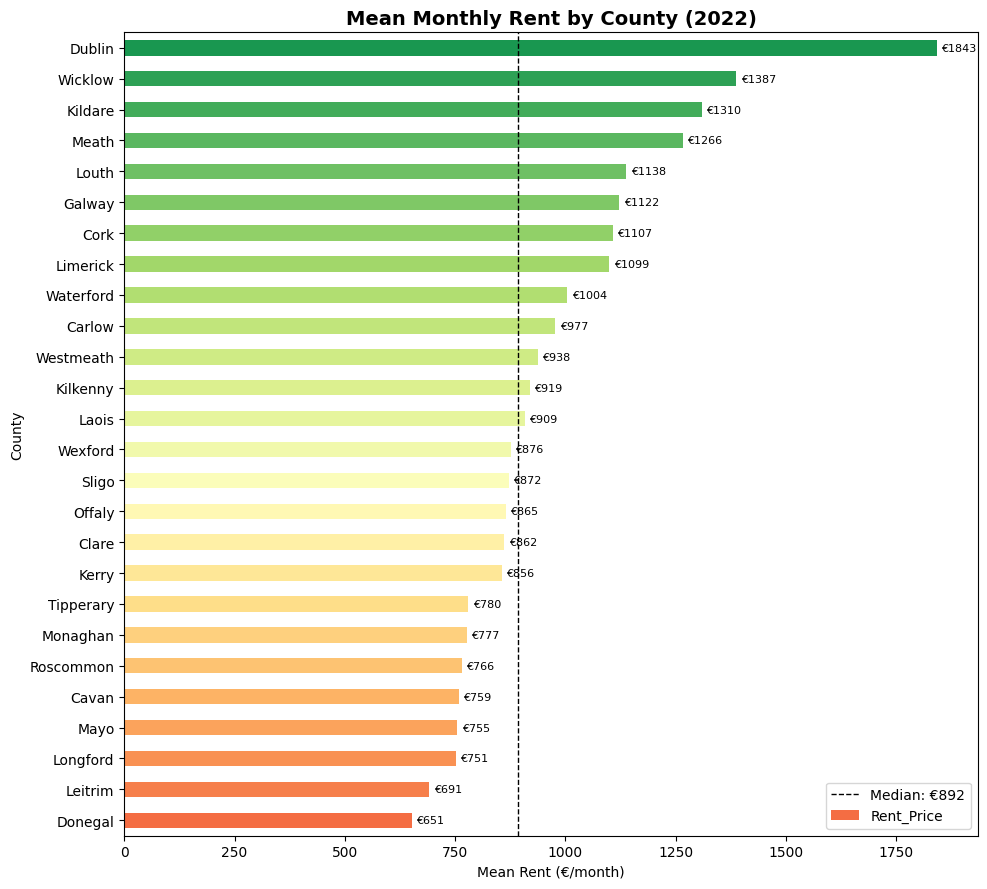

In [36]:
county_rent = df_with_class.groupby('County')['Rent_Price'].mean().sort_values()

county_rent.plot(kind='barh', figsize=(10, 9),
                 color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(county_rent))))

plt.title('Mean Monthly Rent by County (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Rent (€/month)')
plt.axvline(county_rent.median(), color='black', linestyle='--', linewidth=1,
            label=f'Median: €{county_rent.median():.0f}')

for i, val in enumerate(county_rent.values):
    plt.text(val + 10, i, f'€{val:.0f}', va='center', fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Dublin has the highest rents by a considerable distance, sitting at €1,843 a month on average. Wicklow is the next closest at €1,387, there is almost a €500 drop just moving one county over. A lot of that comes down to how concentrated jobs and demand are in Dublin itself. Wicklow, Kildare, and Meath are all elevated too, due to their status as commuter counties pushing average price up. Galway, Cork, and Limerick remain close to each other, hovering between the €1,100 to €1,150 mark, which puts them in a middle ground that is noticeably cheaper than Dublin but still above the median. Counties like Leitrim, Donegal, Longford, and Roscommon are at the bottom, regularly coming in significantly under the median. Looking at the overall shape of it, where you are in the country has a huge bearing on what you pay, which makes county one of the most telling variables in the whole dataset and something any developer would want to understand before picking a location.

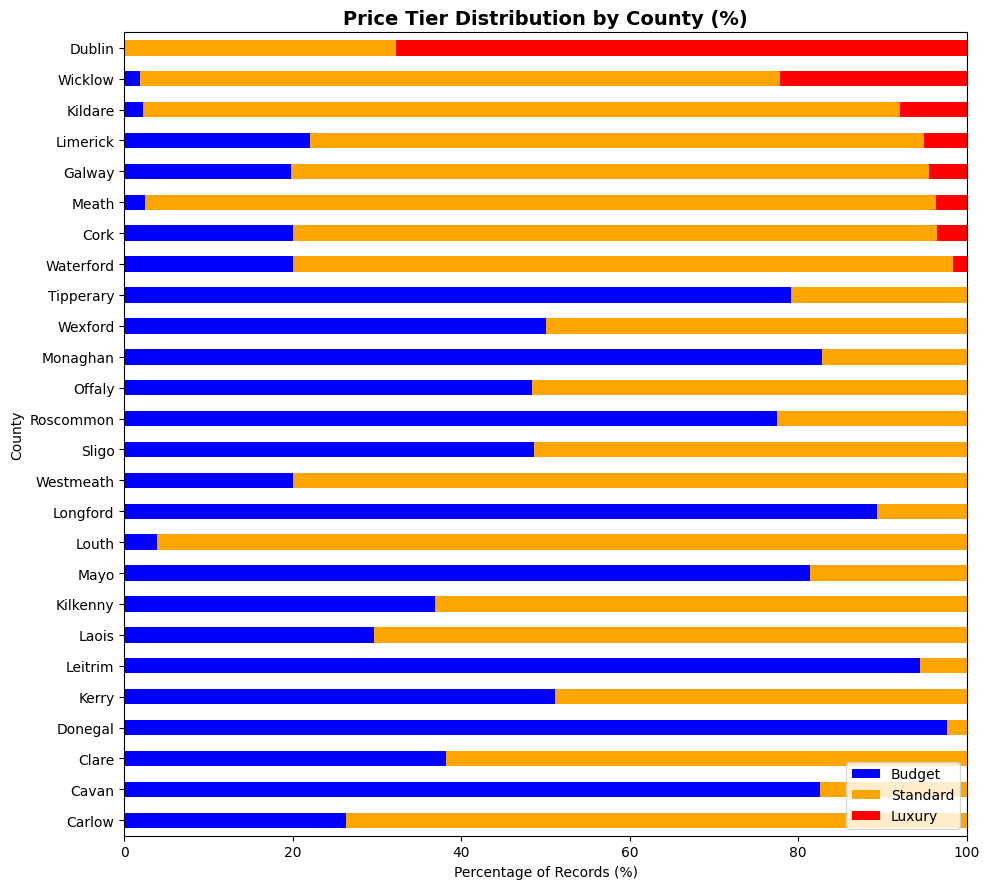

In [37]:
tier_county = df_with_class.groupby(['County', 'Price_Category']).size().unstack(fill_value=0)
tier_county_pct = tier_county.div(tier_county.sum(axis=1), axis=0) * 100
tier_county_pct = tier_county_pct.reindex(columns=['Budget', 'Standard', 'Luxury'])
tier_county_pct = tier_county_pct.sort_values('Luxury', ascending=True)

tier_county_pct.plot(kind='barh', stacked=True, figsize=(10, 9),
                     color=['b', 'orange', 'r'])

plt.title('Price Tier Distribution by County (%)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Records (%)')
plt.xlim(0, 100)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**interpretation:** The tier labels hold up well geographically, which adds confidence to the labelling approach. Dublin is the only county with a meaningful Luxury share, at around 65%, suggesting the 75th percentile threshold is doing a good job of capturing the Dublin premium. Wicklow, Kildare, and Meath are dominated by Standard tier properties with only a small Luxury presence, which makes sense given their high demand but relative distance from the capital. The rural and border counties at the bottom of the chart, including Donegal, Leitrim, Cavan, and Carlow, show almost no Luxury records at all, in line with their lower income levels and land prices. The fact that Luxury properties are so heavily concentrated in Dublin rather than spread across the country suggests the tier labels are reflecting real market conditions rather than appearing by chance.

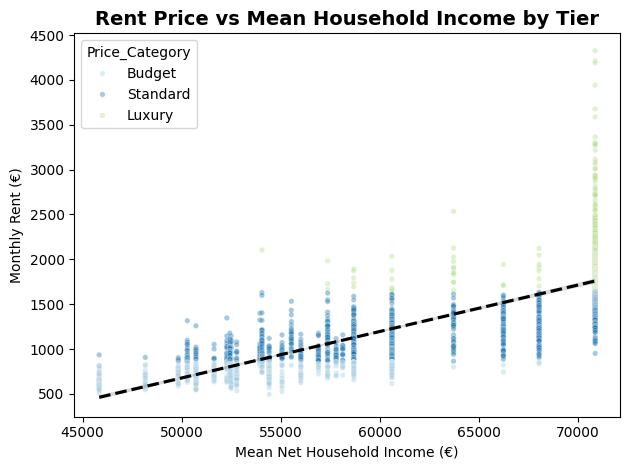

In [38]:
sns.scatterplot(data=df_with_class, x='Net_Income', y='Rent_Price', hue='Price_Category', 
                hue_order=['Budget', 'Standard', 'Luxury'], palette='Paired', alpha=0.4, s=15)

sns.regplot(data=df_with_class, x='Net_Income', y='Rent_Price', scatter=False, 
            line_kws={'color': 'black', 'linestyle': '--'})

plt.title('Rent Price vs Mean Household Income by Tier', fontsize=14, fontweight='bold')
plt.xlabel('Mean Net Household Income (€)')
plt.ylabel('Monthly Rent (€)')
plt.tight_layout()
plt.show()

**Interpretation:** A positive relationship between county-level household income and rent price is clearly visible, with the trend line confirming that higher-income counties command higher monthly rent. Luxury tier records (green) are concentrated almost exclusively at the far right of the x-axis, in counties with mean household income above €70,000, which corresponds to Dublin. Budget tier records (light blue) cluster in lower-income counties below €55,000. The vertical stacking of points at each income value reflects the county-level nature of the income feature, as all properties in the same county share the same income value, producing the characteristic column pattern. This confirms that Net_Income is a strong county-level signal but cannot alone separate tiers within a county, which justifies the multi-feature modelling approach.

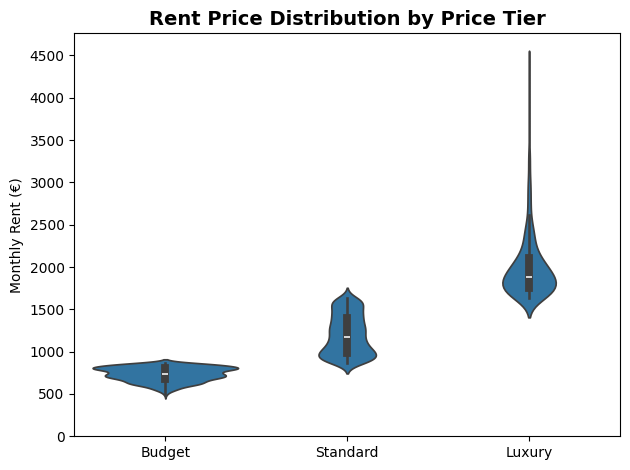

In [39]:
sns.violinplot(data=df_with_class, x='Price_Category', y='Rent_Price',
               order=['Budget', 'Standard', 'Luxury'])

plt.title('Rent Price Distribution by Price Tier', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Monthly Rent (€)')
plt.yticks(range(0, 5000, 500))
plt.tight_layout()
plt.show()

**Interpretation:** The three tiers show clear separation with minimal overlap between Budget and Luxury. Budget rents are tightly concentrated between approximately €500-€900, reflecting consistent low-price stock in rural and border counties. Standard has a wider distribution spanning roughly €800–€1,600, consistent with its role as the mainstream market segment covering commuter belt and regional city properties. Luxury shows the widest and most skewed distribution, with a dense mass around €1,800-€2,000 but a long upper tail extending above €4,000, these extremes are large Dublin properties. The distinct shapes of all three violins validate the percentile-based thresholds as producing meaningfully separated, non-arbitrary classes.

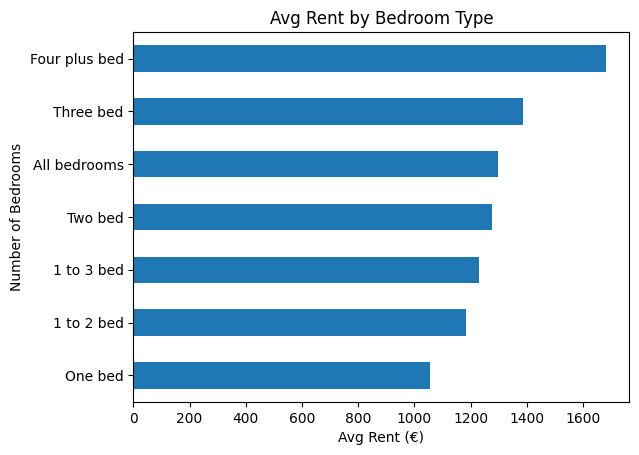

In [ ]:
df_with_class.groupby('Number of Bedrooms')['Rent_Price'].mean().sort_values().plot(kind='barh')
plt.title('Avg Rent by Bedroom Type')
plt.xlabel('Avg Rent (€)')
plt.show()


**Interpretation:** Average rent increases consistently with bedroom count, as expected. Four-plus-bed
properties average a little over €1,600 per month - over 60% more than one-bed units which have an average a little over
€1,000. This monotonic relationship confirms that bedroom count is a meaningful predictor of price tier.
However, the gap between adjacent categories narrows at the upper end (Three bed vs Four plus bed),
suggesting diminishing returns in rental premium for very large properties. The "All bedrooms" aggregate
sits in the middle of the range at roughly €1,300, close to the overall dataset mean. Notably, the
differences between categories are not large enough to determine tier on bedroom count alone, as a
four-plus-bed property in Leitrim and a one-bed in Dublin can occupy the same tier, confirming that
county-level features are essential co-predictors in the classification model.

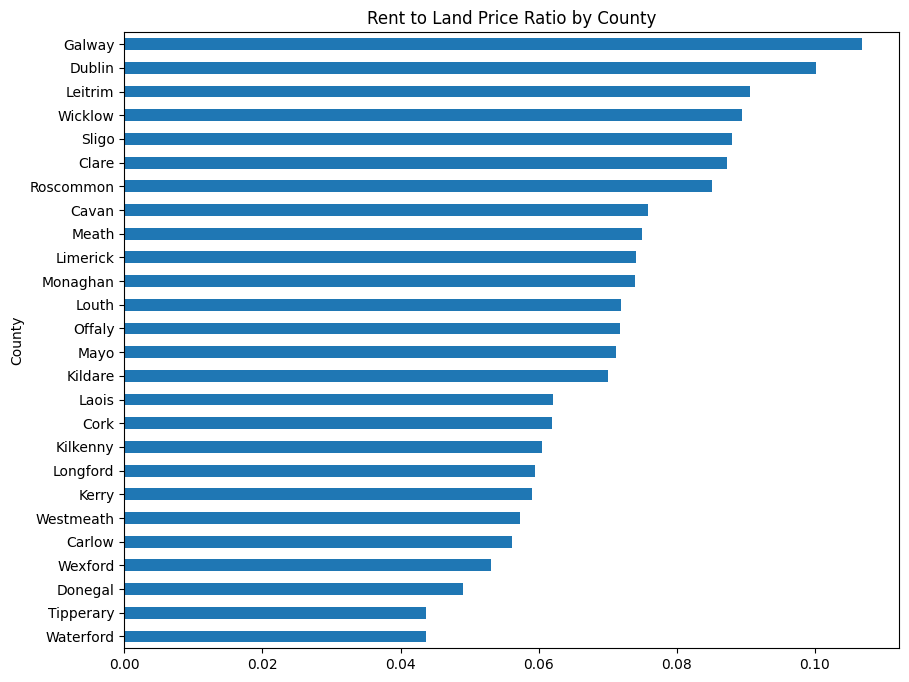

In [42]:
df_with_class.groupby('County')['Rent_Land_Ratio'].mean().sort_values().plot(kind='barh', figsize=(10,8))
plt.title('Rent to Land Price Ratio by County')
plt.show()

**Interpretation:** The Rent-to-Land Ratio measures monthly rental income achievable per unit of land
acquisition cost. Galway tops the ranking with a ratio above
0.10, meaning developers can achieve relatively high rents compared to land costs, making it an
attractive private rental development market. Dublin, despite its high absolute rents, ranks second rather than
first because land prices are also extremely high, compressing the ratio. This is a critical distinction
for the business: the county with the highest rents is not necessarily the most profitable development
location. Leitrim and Wicklow also rank highly. Leitrim due to very low land prices rather than high
rents, Wicklow due to strong rental demand from Dublin commuters. At the lower end, Waterford, Tipperary,
and Donegal offer weak yield ratios, reflecting low rents that are not offset by sufficiently cheap land.
This feature is Ireland-specific in that Irish agricultural land zoning and Local Authority development
levies directly shape the land price component, making it a genuinely local context variable that would
not transfer to a model built on data from another country.

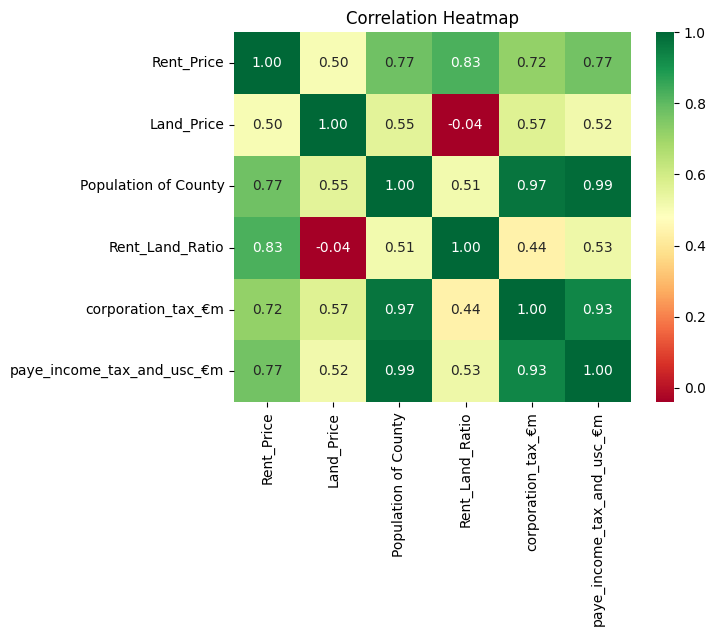

In [43]:
num_cols = ['Rent_Price', 'Land_Price', 'Population of County',
            'Rent_Land_Ratio', 'corporation_tax_€m', 'paye_income_tax_and_usc_€m']
sns.heatmap(df_with_class[num_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()

**Interpretation:** Several important relationships are visible in the correlation matrix. Rent_Price
correlates strongly with Rent_Land_Ratio (0.83) and Population of County (0.77), confirming
that higher-population, higher demand counties drive both rent levels and yield ratios.
paye_income_tax_and_usc_€m correlates at 0.77 with Rent_Price, validating it as a strong predictor
of tier - this Ireland-specific feature (which incorporates the Universal Social Charge) captures county
employment and income levels that directly determine rental affordability and demand. A notable concern
is the near-perfect correlation between Population of County and paye_income_tax_and_usc_€m (0.99)
and corporation_tax_€m (0.97), indicating severe multicollinearity among the tax receipt features.
Including all three in a Logistic Regression model simultaneously would inflate coefficient variance and
reduce interpretability. For the Random Forest model this is less problematic as tree-based methods are
more robust to multicollinearity, but feature selection or PCA should be considered before finalising
the Logistic Regression feature set. Land_Price shows the weakest correlation with Rent_Price (0.50)
and is slightly negatively correlated with Rent_Land_Ratio (−0.04), confirming that high land prices
compress yields - consistent with the Dublin market dynamic observed in the bar charts above.

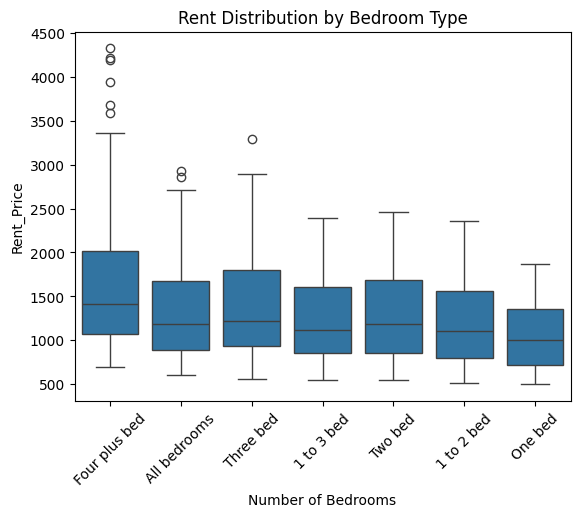

In [44]:
sns.boxplot(data=df_with_class, x='Number of Bedrooms', y='Rent_Price')
plt.xticks(rotation=45)
plt.title('Rent Distribution by Bedroom Type')
plt.show()

**Interpretation:** The boxplot reveals that spread and outlier presence increase significantly with
bedroom size. Four-plus-bed properties have the widest interquartile range (approximately €1,200–€2,000)
and the most extreme outliers, reaching above €4,000 per month - these are exclusively large Dublin
properties. One-bed and two-bed units show tighter distributions with fewer outliers, reflecting more
uniform pricing across counties for smaller stock. The overlapping IQRs across all categories confirm
that bedroom type alone cannot cleanly separate the three price tiers - a three-bed in Cork overlaps
entirely with a one-bed in Dublin. This justifies the multi-feature approach taken in the classifier,
where county economic indicators (PAYE/USC receipts, mean household income, land price) are combined
with bedroom type to produce reliable tier predictions.